Dateset shape after cleaning: (283726, 31)
Training set:
Class
0    226602
1       378
Name: count, dtype: int64

Test set:
Class
0    56651
1       95
Name: count, dtype: int64

Training proportions:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Test proportions:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9474


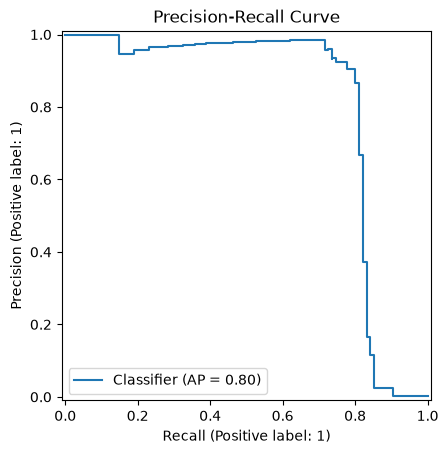

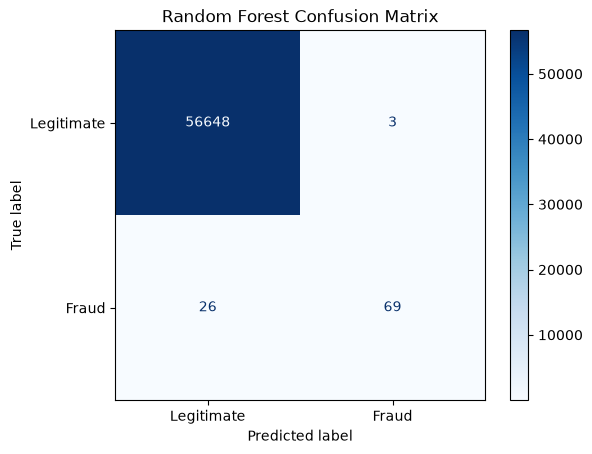

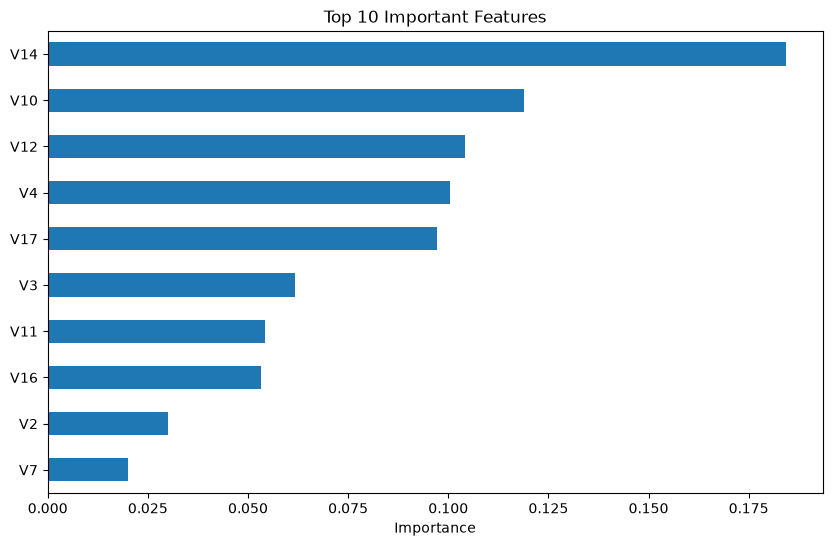

In [1]:
import kagglehub
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(classification_report,
                            confusion_matrix,
                            ConfusionMatrixDisplay,
                            roc_auc_score)
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import RandomizedSearchCV

RANDOM_STATE = 42

#--------------
# Load Dataset
#--------------
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file = Path(path) / "creditcard.csv"
df = pd.read_csv(csv_file)

# Remove duplicate transactions
df = df.drop_duplicates()
print("Dateset shape after cleaning:", df.shape)

#--------------------
# Features und Target
#--------------------
X = df.drop("Class", axis=1)
y = df["Class"]

#--------------------
# Train-Test-Split
#--------------------
stratify = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Training set:")
print(y_train.value_counts())
print("\nTest set:")
print(y_test.value_counts())
print("\nTraining proportions:")
print(y_train.value_counts(normalize=True))
print("\nTest proportions:")
print(y_test.value_counts(normalize=True))

#--------------------------
# Random Forest trainieren
#--------------------------
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                            random_state = RANDOM_STATE, n_jobs = -1)

rf.fit(X_train, y_train)

#--------------------
# Vorhersagen
#--------------------
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:,1]

#--------------------
# Evaluation
#--------------------
print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

#------------------------
# Precision-Recall Curve
#------------------------
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba)
plt.title("Precision-Recall Curve")
plt.show()

#-----------------------
# Confusion Matrix
#-----------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Legitimate", "Fraud"])
disp.plot(cmap = "Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

#-----------------------
# Featrue Importance
#-----------------------
feature_importance = pd.Series(rf.feature_importances_, index = X.columns)
feature_importance = feature_importance.sort_values(ascending = False)
feature_importance.head(10)

plt.figure(figsize=(10, 6))
feature_importance.head(10).sort_values().plot(kind = "barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

Dateset shape after cleaning: (283726, 31)
Training set:
Class
0    226602
1       378
Name: count, dtype: int64

Test set:
Class
0    56651
1       95
Name: count, dtype: int64

Training proportions:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Test proportions:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

Best CV F1:
0.8493989397446428
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9663


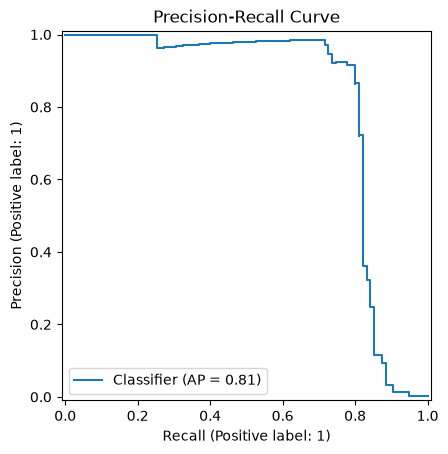

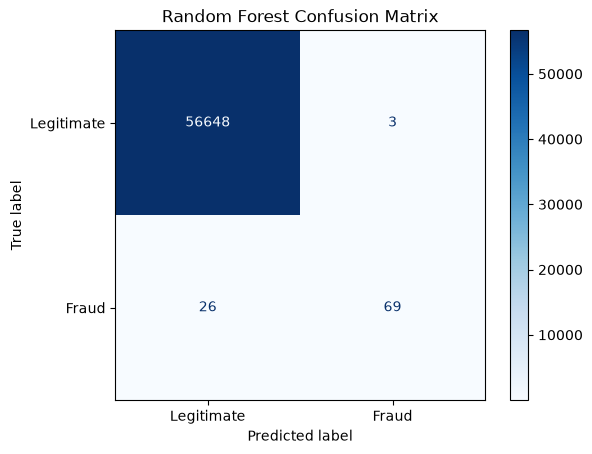

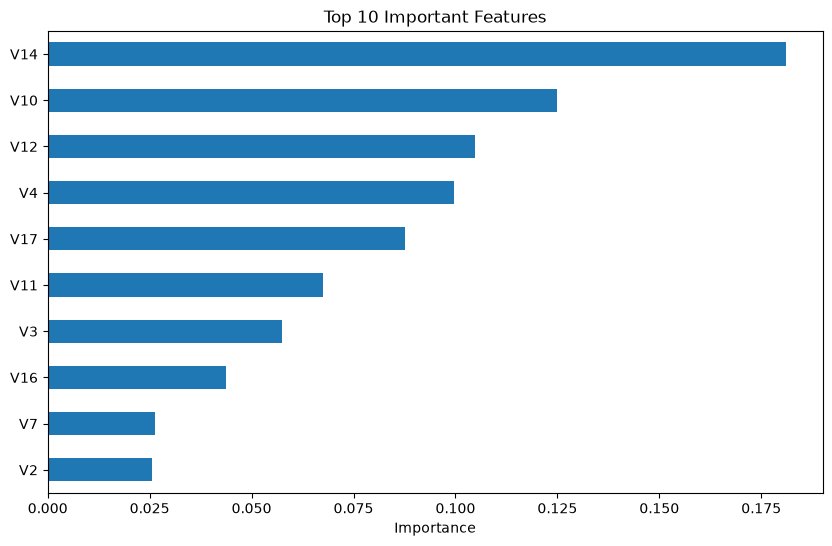

In [5]:
import kagglehub
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(classification_report,
                            confusion_matrix,
                            ConfusionMatrixDisplay,
                            roc_auc_score)
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import RandomizedSearchCV

RANDOM_STATE = 42

#--------------
# Load Dataset
#--------------
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file = Path(path) / "creditcard.csv"
df = pd.read_csv(csv_file)

# Remove duplicate transactions
df = df.drop_duplicates()
print("Dateset shape after cleaning:", df.shape)

#--------------------
# Features und Target
#--------------------
X = df.drop("Class", axis=1)
y = df["Class"]

#--------------------
# Train-Test-Split
#--------------------
stratify = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Training set:")
print(y_train.value_counts())
print("\nTest set:")
print(y_test.value_counts())
print("\nTraining proportions:")
print(y_train.value_counts(normalize=True))
print("\nTest proportions:")
print(y_test.value_counts(normalize=True))

#--------------------------
# Random Forest trainieren
#--------------------------
param_grid = {"n_estimators": [200, 300, 500],
              "max_depth": [10, 15, 20, None],
              "min_samples_split": [2, 5, 10],
              "min_samples_leaf": [1, 2, 4]}

rf = RandomForestClassifier(class_weight="balanced",
                            random_state = RANDOM_STATE, n_jobs = -1)


search = RandomizedSearchCV(rf, param_distributions=param_grid,
                            n_iter = 10, scoring = "f1",cv = 3, n_jobs = -1, random_state = RANDOM_STATE, verbose = 1)
search.fit(X_train, y_train)
rf = search.best_estimator_
print("Best Parameters:")
print(search.best_params_)
print("\nBest CV F1:")
print(search.best_score_)

#--------------------
# Vorhersagen
#--------------------
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:,1]

#--------------------
# Evaluation
#--------------------
print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

#------------------------
# Precision-Recall Curve
#------------------------
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba)
plt.title("Precision-Recall Curve")
plt.show()

#-----------------------
# Confusion Matrix
#-----------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Legitimate", "Fraud"])
disp.plot(cmap = "Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

#-----------------------
# Featrue Importance
#-----------------------
feature_importance = pd.Series(rf.feature_importances_, index = X.columns)
feature_importance = feature_importance.sort_values(ascending = False)
feature_importance.head(10)

plt.figure(figsize=(10, 6))
feature_importance.head(10).sort_values().plot(kind = "barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

## Random Forest Results

The Random Forest classifier achieved strong overall performance on the cleaned dataset.

### Classification Performance

- Precision: 0.96
- Recall: 0.73
- F1-Score: 0.83
- ROC-AUC: 0.966

The model identified 69 of 95 fraudulent transactions while producing only 3 false positive predictions.

This resulted in a very high precision, indicating that transactions classified as fraudulent were highly likely to be actual fraud cases.

### Precision-Recall Analysis

The Precision-Recall Curve achieved an Average Precision (AP) score of approximately 0.81.

Compared to Logistic Regression, the Random Forest model provides a substantially better balance between precision and recall, making it more suitable for fraud detection in highly imbalanced datasets.

### Feature Importance

Feature importance analysis revealed that the most influential predictors were:

- V14
- V10
- V12
- V4
- V17

These findings closely align with the results of the exploratory data analysis, where the same variables exhibited the strongest correlations with fraudulent activity.

### Model Interpretation

The Random Forest classifier achieved the best overall performance among the evaluated supervised learning models.

Although recall is slightly lower than the optimized Logistic Regression model, the substantial improvement in precision leads to a significantly higher F1-score and a much lower number of false positive predictions.

This makes Random Forest a strong candidate for practical fraud detection systems where minimizing false alarms is important.

### Hyperparameter Optimization

RandomizedSearchCV was used to optimize the Random Forest classifier.

Best parameters:

- n_estimators = 500
- max_depth = None
- min_samples_split = 2
- min_samples_leaf = 1

The optimized configuration achieved a cross-validation F1-score of 0.849, confirming that the selected model configuration is close to the optimal solution for this dataset.